In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# importing dataset from local drive environment
# df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/AI-Project/original_dataset.csv')




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Initial EDA

In [ ]:
df.head(10)

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,10811496,K00753.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509
5,6,10872983,K00756.01,Kepler-228 d,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-232.0,4.486,0.054,-0.229,0.972,0.315,-0.105,296.28613,48.224670,15.714
6,7,10872983,K00756.02,Kepler-228 c,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-232.0,4.486,0.054,-0.229,0.972,0.315,-0.105,296.28613,48.224670,15.714
7,8,10872983,K00756.03,Kepler-228 b,CONFIRMED,CANDIDATE,0.992,0,0,0,...,-232.0,4.486,0.054,-0.229,0.972,0.315,-0.105,296.28613,48.224670,15.714
8,9,6721123,K00114.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,1,...,-124.0,3.986,0.182,-0.098,1.958,0.322,-0.483,298.86435,42.151569,12.660
9,10,10910878,K00757.01,Kepler-229 c,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-83.0,4.485,0.083,-0.028,0.848,0.033,-0.072,286.99948,48.375790,15.841


how many rows and columns?

In [ ]:
df.shape

(9564, 50)

what are the features and their datatypes?

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 50 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rowid              9564 non-null   int64  
 1   kepid              9564 non-null   int64  
 2   kepoi_name         9564 non-null   object 
 3   kepler_name        2294 non-null   object 
 4   koi_disposition    9564 non-null   object 
 5   koi_pdisposition   9564 non-null   object 
 6   koi_score          8054 non-null   float64
 7   koi_fpflag_nt      9564 non-null   int64  
 8   koi_fpflag_ss      9564 non-null   int64  
 9   koi_fpflag_co      9564 non-null   int64  
 10  koi_fpflag_ec      9564 non-null   int64  
 11  koi_period         9564 non-null   float64
 12  koi_period_err1    9110 non-null   float64
 13  koi_period_err2    9110 non-null   float64
 14  koi_time0bk        9564 non-null   float64
 15  koi_time0bk_err1   9110 non-null   float64
 16  koi_time0bk_err2   9110 

which features have null values, with percentage?

In [ ]:
features_with_nulls = df.isnull().sum().sort_values(ascending=False)
features_with_nulls

,0
koi_teq_err2,9564
koi_teq_err1,9564
kepler_name,7270
koi_score,1510
koi_steff_err2,483
koi_srad_err2,468
koi_srad_err1,468
koi_steff_err1,468
koi_slogg_err2,468
koi_slogg_err1,468


In [ ]:
features_with_nulls_percentage = (df.isnull().sum() / df.shape[0]).sort_values(ascending=False)
features_with_nulls_percentage

,0
koi_teq_err2,1.000000
koi_teq_err1,1.000000
kepler_name,0.760142
koi_score,0.157884
koi_steff_err2,0.050502
koi_srad_err2,0.048934
koi_srad_err1,0.048934
koi_steff_err1,0.048934
koi_slogg_err2,0.048934
koi_slogg_err1,0.048934


We will remove the two features with entirely null values

#Preprocessing

In [ ]:
df_no_nulls = df.drop(columns=['koi_teq_err1', 'koi_teq_err2'])
print(f"Original DataFrame shape: {df.shape}")
print(f"New DataFrame shape after dropping columns: {df_no_nulls.shape}")

Original DataFrame shape: (9564, 50)
New DataFrame shape after dropping columns: (9564, 48)


In [ ]:
df_no_nulls

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,10811496,K00753.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9559,9560,10031643,K07984.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,0,0,...,-152.0,4.296,0.231,-0.189,1.088,0.313,-0.228,298.74921,46.973351,14.478
9560,9561,10090151,K07985.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,1,...,-166.0,4.529,0.035,-0.196,0.903,0.237,-0.079,297.18875,47.093819,14.082
9561,9562,10128825,K07986.01,NaN,CANDIDATE,CANDIDATE,0.497,0,0,0,...,-220.0,4.444,0.056,-0.224,1.031,0.341,-0.114,286.50937,47.163219,14.757
9562,9563,10147276,K07987.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.021,0,0,1,...,-236.0,4.447,0.056,-0.224,1.041,0.341,-0.114,294.16489,47.176281,15.385


removing unnecessary columns:

rowid: A simple index for the dataset.  
kepid: The ID number for the target star.  
kepoi_name: The tracking number for the potential planet.  
kepler_name: This is a major leakage risk because only confirmed planets get these names; if this column is populated, the answer is already "Confirmed".

koi_pdisposition: This is the automated guess made by the Kepler pipeline before human review. Including it makes the task too easy and prevents the model from learning from the raw physics data.  
koi_score: This is a 0 to 1 confidence score generated by the pipeline. Like the pdisposition, it is a result of previous modeling rather than a raw physical observation.  

koi_tce_delivname: This is an internal batch name for the data delivery.  
koi_comment: This is a text note explaining why an object was a false positive. Machine learning models cannot easily use this raw text alongside numerical data. This has already been removed.
koi_datalink_dvr and koi_datalink_dvs: These are web links to NASA reports. These have already been removed.



In [ ]:
# list of the columns to remove
to_drop = [
    'rowid', 'kepid', 'kepoi_name', 'kepler_name', 'koi_pdisposition',
    'koi_score', 'koi_tce_delivname']

# drop them from dataframe
df_dropped_cols = df_no_nulls.drop(columns=to_drop)
df_dropped_cols

,koi_disposition,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_period_err1,koi_period_err2,koi_time0bk,koi_time0bk_err1,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,CONFIRMED,0,0,0,0,9.488036,2.775000e-05,-2.775000e-05,170.538750,0.002160,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,CONFIRMED,0,0,0,0,54.418383,2.479000e-04,-2.479000e-04,162.513840,0.003520,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,FALSE POSITIVE,0,1,0,0,19.899140,1.494000e-05,-1.494000e-05,175.850252,0.000581,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,FALSE POSITIVE,0,1,0,0,1.736952,2.630000e-07,-2.630000e-07,170.307565,0.000115,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,CONFIRMED,0,0,0,0,2.525592,3.761000e-06,-3.761000e-06,171.595550,0.001130,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9559,FALSE POSITIVE,0,0,0,1,8.589871,1.846000e-04,-1.846000e-04,132.016100,0.015700,...,-152.0,4.296,0.231,-0.189,1.088,0.313,-0.228,298.74921,46.973351,14.478
9560,FALSE POSITIVE,0,1,1,0,0.527699,1.160000e-07,-1.160000e-07,131.705093,0.000170,...,-166.0,4.529,0.035,-0.196,0.903,0.237,-0.079,297.18875,47.093819,14.082
9561,CANDIDATE,0,0,0,0,1.739849,1.780000e-05,-1.780000e-05,133.001270,0.007690,...,-220.0,4.444,0.056,-0.224,1.031,0.341,-0.114,286.50937,47.163219,14.757
9562,FALSE POSITIVE,0,0,1,0,0.681402,2.434000e-06,-2.434000e-06,132.181750,0.002850,...,-236.0,4.447,0.056,-0.224,1.041,0.341,-0.114,294.16489,47.176281,15.385


In [ ]:
df_dropped_cols.columns

Index(['koi_disposition', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co',
       'koi_fpflag_ec', 'koi_period', 'koi_period_err1', 'koi_period_err2',
       'koi_time0bk', 'koi_time0bk_err1', 'koi_time0bk_err2', 'koi_impact',
       'koi_impact_err1', 'koi_impact_err2', 'koi_duration',
       'koi_duration_err1', 'koi_duration_err2', 'koi_depth', 'koi_depth_err1',
       'koi_depth_err2', 'koi_prad', 'koi_prad_err1', 'koi_prad_err2',
       'koi_teq', 'koi_insol', 'koi_insol_err1', 'koi_insol_err2',
       'koi_model_snr', 'koi_tce_plnt_num', 'koi_steff', 'koi_steff_err1',
       'koi_steff_err2', 'koi_slogg', 'koi_slogg_err1', 'koi_slogg_err2',
       'koi_srad', 'koi_srad_err1', 'koi_srad_err2', 'ra', 'dec',
       'koi_kepmag'],
      dtype='object')

The error columns are for the scientists doing the measurements, to measure their error in measurement. we don't need them; also removing them.

In [ ]:
error_columns = ["koi_period_err1", "koi_period_err2", "koi_time0bk_err1", 'koi_time0bk_err2',
                 'koi_impact_err1',  'koi_impact_err2', 'koi_duration_err1', 'koi_duration_err2',
                 'koi_depth_err1', 'koi_depth_err2',
                 'koi_prad_err1', 'koi_prad_err2', 'koi_insol_err1', 'koi_insol_err2',
                 'koi_steff_err1', 'koi_steff_err2', 'koi_slogg_err1', 'koi_slogg_err2',
                 'koi_srad_err1', 'koi_srad_err2']

df_no_errors = df_dropped_cols.drop(columns=error_columns)
df_no_errors

,koi_disposition,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_time0bk,koi_impact,koi_duration,koi_depth,...,koi_teq,koi_insol,koi_model_snr,koi_tce_plnt_num,koi_steff,koi_slogg,koi_srad,ra,dec,koi_kepmag
0,CONFIRMED,0,0,0,0,9.488036,170.538750,0.146,2.95750,615.8,...,793.0,93.59,35.8,1.0,5455.0,4.467,0.927,291.93423,48.141651,15.347
1,CONFIRMED,0,0,0,0,54.418383,162.513840,0.586,4.50700,874.8,...,443.0,9.11,25.8,2.0,5455.0,4.467,0.927,291.93423,48.141651,15.347
2,FALSE POSITIVE,0,1,0,0,19.899140,175.850252,0.969,1.78220,10829.0,...,638.0,39.30,76.3,1.0,5853.0,4.544,0.868,297.00482,48.134129,15.436
3,FALSE POSITIVE,0,1,0,0,1.736952,170.307565,1.276,2.40641,8079.2,...,1395.0,891.96,505.6,1.0,5805.0,4.564,0.791,285.53461,48.285210,15.597
4,CONFIRMED,0,0,0,0,2.525592,171.595550,0.701,1.65450,603.3,...,1406.0,926.16,40.9,1.0,6031.0,4.438,1.046,288.75488,48.226200,15.509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9559,FALSE POSITIVE,0,0,0,1,8.589871,132.016100,0.765,4.80600,87.7,...,929.0,176.40,8.4,1.0,5638.0,4.296,1.088,298.74921,46.973351,14.478
9560,FALSE POSITIVE,0,1,1,0,0.527699,131.705093,1.252,3.22210,1579.2,...,2088.0,4500.53,453.3,1.0,5638.0,4.529,0.903,297.18875,47.093819,14.082
9561,CANDIDATE,0,0,0,0,1.739849,133.001270,0.043,3.11400,48.5,...,1608.0,1585.81,10.6,1.0,6119.0,4.444,1.031,286.50937,47.163219,14.757
9562,FALSE POSITIVE,0,0,1,0,0.681402,132.181750,0.147,0.86500,103.6,...,2218.0,5713.41,12.3,1.0,6173.0,4.447,1.041,294.16489,47.176281,15.385


further column drop:

'koi_tce_plnt_num' is an internal pipeline tracking number; not necessary for prediction


In [ ]:
additional_drops = ['koi_tce_plnt_num']
df_final_cols = df_no_errors.drop(columns=additional_drops)
df_final_cols

,koi_disposition,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_time0bk,koi_impact,koi_duration,koi_depth,koi_prad,koi_teq,koi_insol,koi_model_snr,koi_steff,koi_slogg,koi_srad,ra,dec,koi_kepmag
0,CONFIRMED,0,0,0,0,9.488036,170.538750,0.146,2.95750,615.8,2.26,793.0,93.59,35.8,5455.0,4.467,0.927,291.93423,48.141651,15.347
1,CONFIRMED,0,0,0,0,54.418383,162.513840,0.586,4.50700,874.8,2.83,443.0,9.11,25.8,5455.0,4.467,0.927,291.93423,48.141651,15.347
2,FALSE POSITIVE,0,1,0,0,19.899140,175.850252,0.969,1.78220,10829.0,14.60,638.0,39.30,76.3,5853.0,4.544,0.868,297.00482,48.134129,15.436
3,FALSE POSITIVE,0,1,0,0,1.736952,170.307565,1.276,2.40641,8079.2,33.46,1395.0,891.96,505.6,5805.0,4.564,0.791,285.53461,48.285210,15.597
4,CONFIRMED,0,0,0,0,2.525592,171.595550,0.701,1.65450,603.3,2.75,1406.0,926.16,40.9,6031.0,4.438,1.046,288.75488,48.226200,15.509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9559,FALSE POSITIVE,0,0,0,1,8.589871,132.016100,0.765,4.80600,87.7,1.11,929.0,176.40,8.4,5638.0,4.296,1.088,298.74921,46.973351,14.478
9560,FALSE POSITIVE,0,1,1,0,0.527699,131.705093,1.252,3.22210,1579.2,29.35,2088.0,4500.53,453.3,5638.0,4.529,0.903,297.18875,47.093819,14.082
9561,CANDIDATE,0,0,0,0,1.739849,133.001270,0.043,3.11400,48.5,0.72,1608.0,1585.81,10.6,6119.0,4.444,1.031,286.50937,47.163219,14.757
9562,FALSE POSITIVE,0,0,1,0,0.681402,132.181750,0.147,0.86500,103.6,1.07,2218.0,5713.41,12.3,6173.0,4.447,1.041,294.16489,47.176281,15.385


20 columns is a good number of features.

In [ ]:
df_final_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   koi_disposition  9564 non-null   object 
 1   koi_fpflag_nt    9564 non-null   int64  
 2   koi_fpflag_ss    9564 non-null   int64  
 3   koi_fpflag_co    9564 non-null   int64  
 4   koi_fpflag_ec    9564 non-null   int64  
 5   koi_period       9564 non-null   float64
 6   koi_time0bk      9564 non-null   float64
 7   koi_impact       9201 non-null   float64
 8   koi_duration     9564 non-null   float64
 9   koi_depth        9201 non-null   float64
 10  koi_prad         9201 non-null   float64
 11  koi_teq          9201 non-null   float64
 12  koi_insol        9243 non-null   float64
 13  koi_model_snr    9201 non-null   float64
 14  koi_steff        9201 non-null   float64
 15  koi_slogg        9201 non-null   float64
 16  koi_srad         9201 non-null   float64
 17  ra            

what are the classes in koi_disposition?

In [ ]:
df_final_cols['koi_disposition'].value_counts()

,count
koi_disposition,
FALSE POSITIVE,5023
CONFIRMED,2293
CANDIDATE,2248


CANDIDATE class are those instances for which classification is uncertain; will remove them for training purposes.

In [ ]:
df_final_cols = df_final_cols[df_final_cols['koi_disposition'] != 'CANDIDATE']
df_final_cols['koi_disposition'].value_counts()


,count
koi_disposition,
FALSE POSITIVE,5023
CONFIRMED,2293


In [ ]:
df_final_cols.head()

,koi_disposition,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_time0bk,koi_impact,koi_duration,koi_depth,koi_prad,koi_teq,koi_insol,koi_model_snr,koi_steff,koi_slogg,koi_srad,ra,dec,koi_kepmag
0,CONFIRMED,0,0,0,0,9.488036,170.538750,0.146,2.95750,615.8,2.26,793.0,93.59,35.8,5455.0,4.467,0.927,291.93423,48.141651,15.347
1,CONFIRMED,0,0,0,0,54.418383,162.513840,0.586,4.50700,874.8,2.83,443.0,9.11,25.8,5455.0,4.467,0.927,291.93423,48.141651,15.347
2,FALSE POSITIVE,0,1,0,0,19.899140,175.850252,0.969,1.78220,10829.0,14.60,638.0,39.30,76.3,5853.0,4.544,0.868,297.00482,48.134129,15.436
3,FALSE POSITIVE,0,1,0,0,1.736952,170.307565,1.276,2.40641,8079.2,33.46,1395.0,891.96,505.6,5805.0,4.564,0.791,285.53461,48.285210,15.597
4,CONFIRMED,0,0,0,0,2.525592,171.595550,0.701,1.65450,603.3,2.75,1406.0,926.16,40.9,6031.0,4.438,1.046,288.75488,48.226200,15.509


What is the new shape of our data after cleaning?

In [ ]:
df_final_cols.shape

(7316, 20)

By removing CANDIDATE we have removed roughly 2000 rows.

Dealing with remaining null values

In [ ]:
df_final_cols.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7316 entries, 0 to 9563
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   koi_disposition  7316 non-null   object 
 1   koi_fpflag_nt    7316 non-null   int64  
 2   koi_fpflag_ss    7316 non-null   int64  
 3   koi_fpflag_co    7316 non-null   int64  
 4   koi_fpflag_ec    7316 non-null   int64  
 5   koi_period       7316 non-null   float64
 6   koi_time0bk      7316 non-null   float64
 7   koi_impact       7016 non-null   float64
 8   koi_duration     7316 non-null   float64
 9   koi_depth        7016 non-null   float64
 10  koi_prad         7016 non-null   float64
 11  koi_teq          7016 non-null   float64
 12  koi_insol        7057 non-null   float64
 13  koi_model_snr    7016 non-null   float64
 14  koi_steff        7016 non-null   float64
 15  koi_slogg        7016 non-null   float64
 16  koi_srad         7016 non-null   float64
 17  ra               73

deleting null rows simply because it is observed data; we cannot impute. we have enough rows so we dont need to be worried about data loss.

In [ ]:
df_final_cols = df_final_cols.dropna()

df_final_cols.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7015 entries, 0 to 9563
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   koi_disposition  7015 non-null   object 
 1   koi_fpflag_nt    7015 non-null   int64  
 2   koi_fpflag_ss    7015 non-null   int64  
 3   koi_fpflag_co    7015 non-null   int64  
 4   koi_fpflag_ec    7015 non-null   int64  
 5   koi_period       7015 non-null   float64
 6   koi_time0bk      7015 non-null   float64
 7   koi_impact       7015 non-null   float64
 8   koi_duration     7015 non-null   float64
 9   koi_depth        7015 non-null   float64
 10  koi_prad         7015 non-null   float64
 11  koi_teq          7015 non-null   float64
 12  koi_insol        7015 non-null   float64
 13  koi_model_snr    7015 non-null   float64
 14  koi_steff        7015 non-null   float64
 15  koi_slogg        7015 non-null   float64
 16  koi_srad         7015 non-null   float64
 17  ra               70

By deleting remaining nulls we have 7015 instances left.

Renaming columns to something more intuitive

In [ ]:
rename_map = {
    'koi_disposition': 'Disposition',
    'koi_fpflag_nt': 'is_telescopeGlitch',
    'koi_fpflag_ss': 'is_anotherStarBlocking',
    'koi_fpflag_co': 'is_fromBackgroundStar',
    'koi_fpflag_ec': 'isKnownContaminate',
    'koi_period': 'exoplanetYearInDays',
    'koi_time0bk': 'astronomicalTimeWhenDetected',
    'koi_impact': 'distanceFromStarCenter',
    'koi_duration': 'transitDuration',
    'koi_depth': 'percentageBlockedStarlight',
    'koi_prad': 'planetaryRadiusInEarths',
    'koi_teq': 'planetSurfaceTemp',
    'koi_insol': 'planetarySolarRadiationInEarths',
    'koi_model_snr': 'SNR_ratio',
    'koi_steff': 'starSurfaceTemp',
    'koi_slogg': 'starSurfaceGravity',
    'koi_srad': 'starSizeInSuns',
    'ra': 'longitudeStarInSky',
    'dec': 'latitudeStarInSky',
    'koi_kepmag': 'starBrightnessFromKepler'
}

df_cleaned = df_final_cols.rename(columns=rename_map)

# In-Depth EDA

In [ ]:
df_cleaned.describe()

,is_telescopeGlitch,is_anotherStarBlocking,is_fromBackgroundStar,isKnownContaminate,exoplanetYearInDays,astronomicalTimeWhenDetected,distanceFromStarCenter,transitDuration,percentageBlockedStarlight,planetaryRadiusInEarths,planetSurfaceTemp,planetarySolarRadiationInEarths,SNR_ratio,starSurfaceTemp,starSurfaceGravity,starSizeInSuns,longitudeStarInSky,latitudeStarInSky,starBrightnessFromKepler
count,7015.000000,7015.000000,7015.000000,7015.000000,7015.000000,7015.000000,7015.000000,7015.000000,7.015000e+03,7015.000000,7015.000000,7.015000e+03,7015.000000,7015.000000,7015.000000,7015.000000,7015.000000,7015.000000,7015.000000
mean,0.223949,0.307627,0.263435,0.162509,56.571983,163.954303,0.796721,5.916695,3.061916e+04,129.985577,1148.566643,8.451804e+03,326.648239,5727.699359,4.303496,1.779399,292.148309,43.771819,14.253570
std,0.416918,0.461544,0.440528,0.368943,119.912971,64.595189,3.668884,7.002675,9.288057e+04,3519.874708,898.387364,1.606722e+05,891.730440,825.280125,0.444655,6.203561,4.734368,3.600416,1.400114
min,0.000000,0.000000,0.000000,0.000000,0.241843,120.515914,0.000000,0.104600,8.000000e-01,0.080000,92.000000,2.000000e-02,0.000000,2661.000000,0.047000,0.116000,279.852720,36.577381,6.966000
25%,0.000000,0.000000,0.000000,0.000000,2.199067,132.559922,0.224000,2.559650,1.845000e+02,1.520000,559.000000,2.307000e+01,14.700000,5320.000000,4.206500,0.829000,288.861315,40.719870,13.424000
50%,0.000000,0.000000,0.000000,0.000000,8.214299,136.545280,0.576000,3.950000,5.073000e+02,2.680000,928.000000,1.751700e+02,30.700000,5779.000000,4.438000,1.000000,292.305940,43.621220,14.496000
75%,0.000000,1.000000,1.000000,0.000000,31.856147,170.545074,0.916000,6.472000,2.768400e+03,25.435000,1496.500000,1.185885e+03,123.000000,6126.000000,4.543000,1.367000,295.938815,46.697775,15.308500
max,1.000000,1.000000,1.000000,1.000000,1071.232624,1472.522306,100.806000,138.540000,1.541400e+06,200346.000000,14667.000000,1.094755e+07,9054.700000,15896.000000,5.283000,229.908000,301.720760,52.336010,20.003000


Very different scales. Scaling will be required

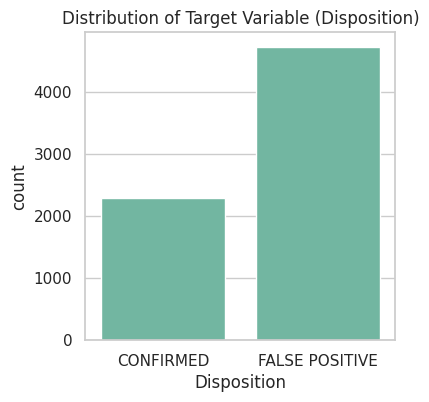

In [ ]:
# 1. class distribution
plt.figure(figsize=(4, 4))
sns.countplot(data=df_cleaned, x='Disposition')
plt.title('Distribution of Target Variable (Disposition)')
plt.savefig('class_distribution.png')

Most are false positives. Imbalanced dataset

Encoding target feature

In [ ]:
# for correlation matrix and later the model we label all categorical features as numerical
df_cleaned['Disposition'] = df_cleaned['Disposition'].replace(
    {'CONFIRMED': 1,
     'FALSE POSITIVE': 0}
    )

df_cleaned['Disposition'].value_counts()

/tmp/ipykernel_827/3812092799.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cleaned['Disposition'] = df_cleaned['Disposition'].replace(


,count
Disposition,
0,4723
1,2292


In [ ]:
# to download the cleaned and labeled dataset locally and then manually to drive
df_cleaned.to_csv('df_cleaned_labeled.csv', index=False)
from google.colab import files
files.download('df_cleaned_labeled.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

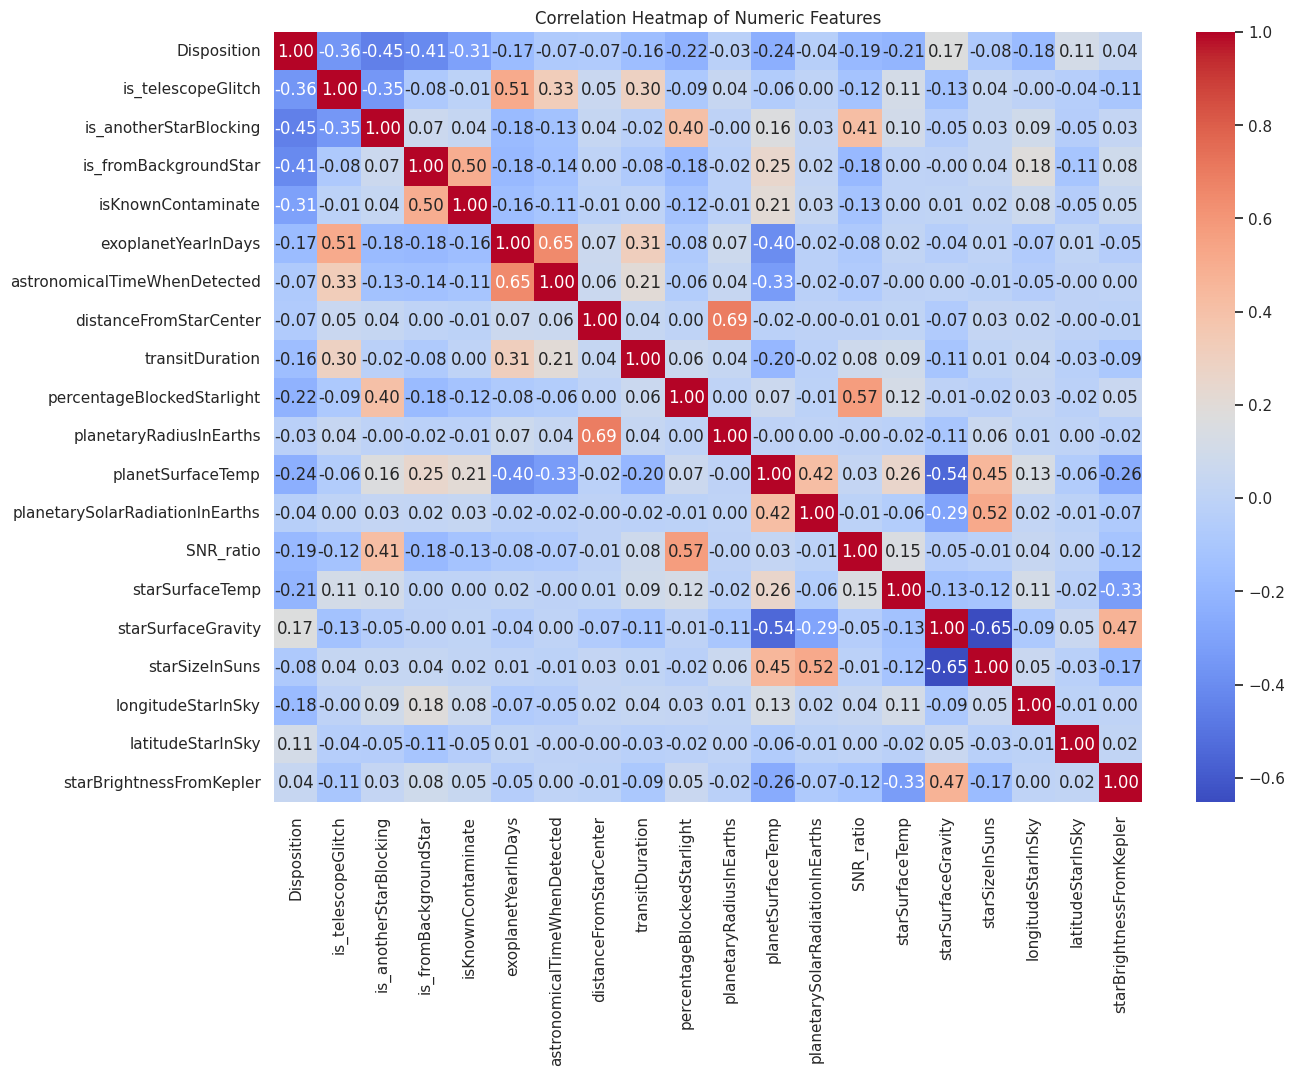

In [ ]:


corr_matrix = df_cleaned.corr()

# correlation Heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f") # include coefficients in each square up to 2 decimal points
plt.title('Correlation Heatmap of Numeric Features')
plt.savefig('correlation_heatmap.png')

Correlations between variables are generally weak; features have weak linear relationships with eachother

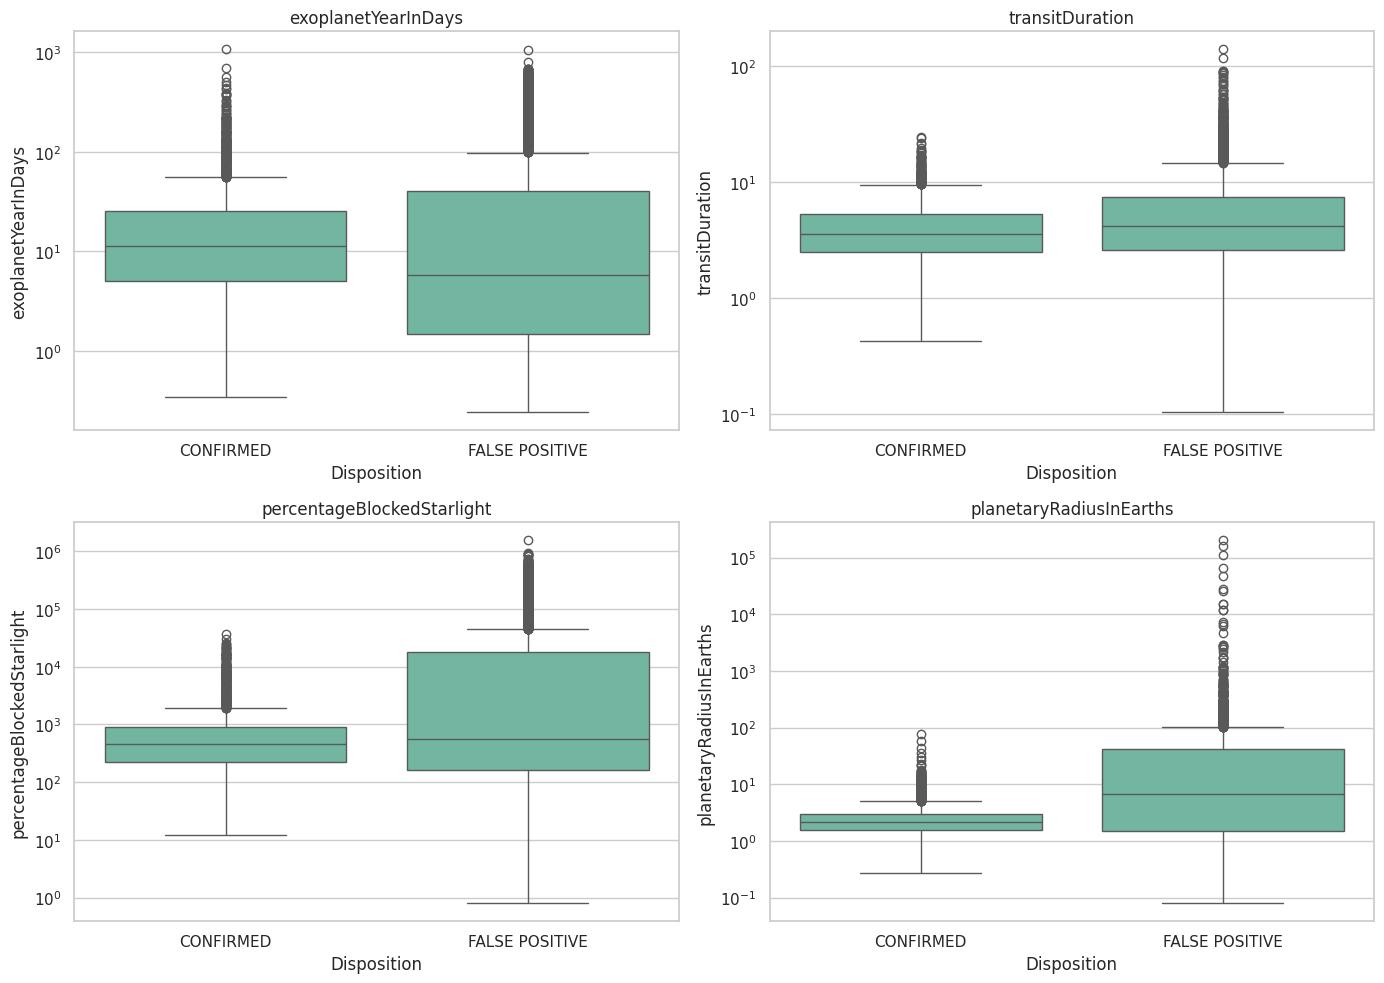

In [ ]:
# boxplots for a few interesting features by class
features_to_plot = ['exoplanetYearInDays', 'transitDuration', 'percentageBlockedStarlight', 'planetaryRadiusInEarths']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# for easier reading of figure we temporarily change back the target feature labels
df_cleaned['Disposition'] = df_cleaned['Disposition'].replace(
    {1: 'CONFIRMED',
     0: 'FALSE POSITIVE'}
    )

df_cleaned['Disposition'].value_counts()
for i, col in tuple(enumerate(features_to_plot)):
    # using log scale for y because astronomical data has extreme outliers/ranges
    sns.boxplot(data=df_cleaned, x='Disposition', y=col, ax=axes[i])
    axes[i].set_yscale('log') # because figures are large with many outliers
    axes[i].set_title(f'{col}')

plt.tight_layout()
plt.savefig('boxplots_features.png')

The box and whisker plots reveal significant differences in the distribution and scale of features between "CONFIRMED" exoplanets and "FALSE POSITIVE" signals. Notably, False Positives have much wider ranges and more extreme outliers across most features, which is why we use a logarithmic scale. For instance, the planetary radius (planetaryRadiusInEarths) and transit depth (percentageBlockedStarlight) for Confirmed planets are tightly clustered at much lower median values, representing physically realistic planetary sizes. In contrast, False Positives show massive spread and extreme upper values, which indicate that the object blocking the light is actually another massive star (an eclipsing binary) rather than a planet.

Distributions of Several Features

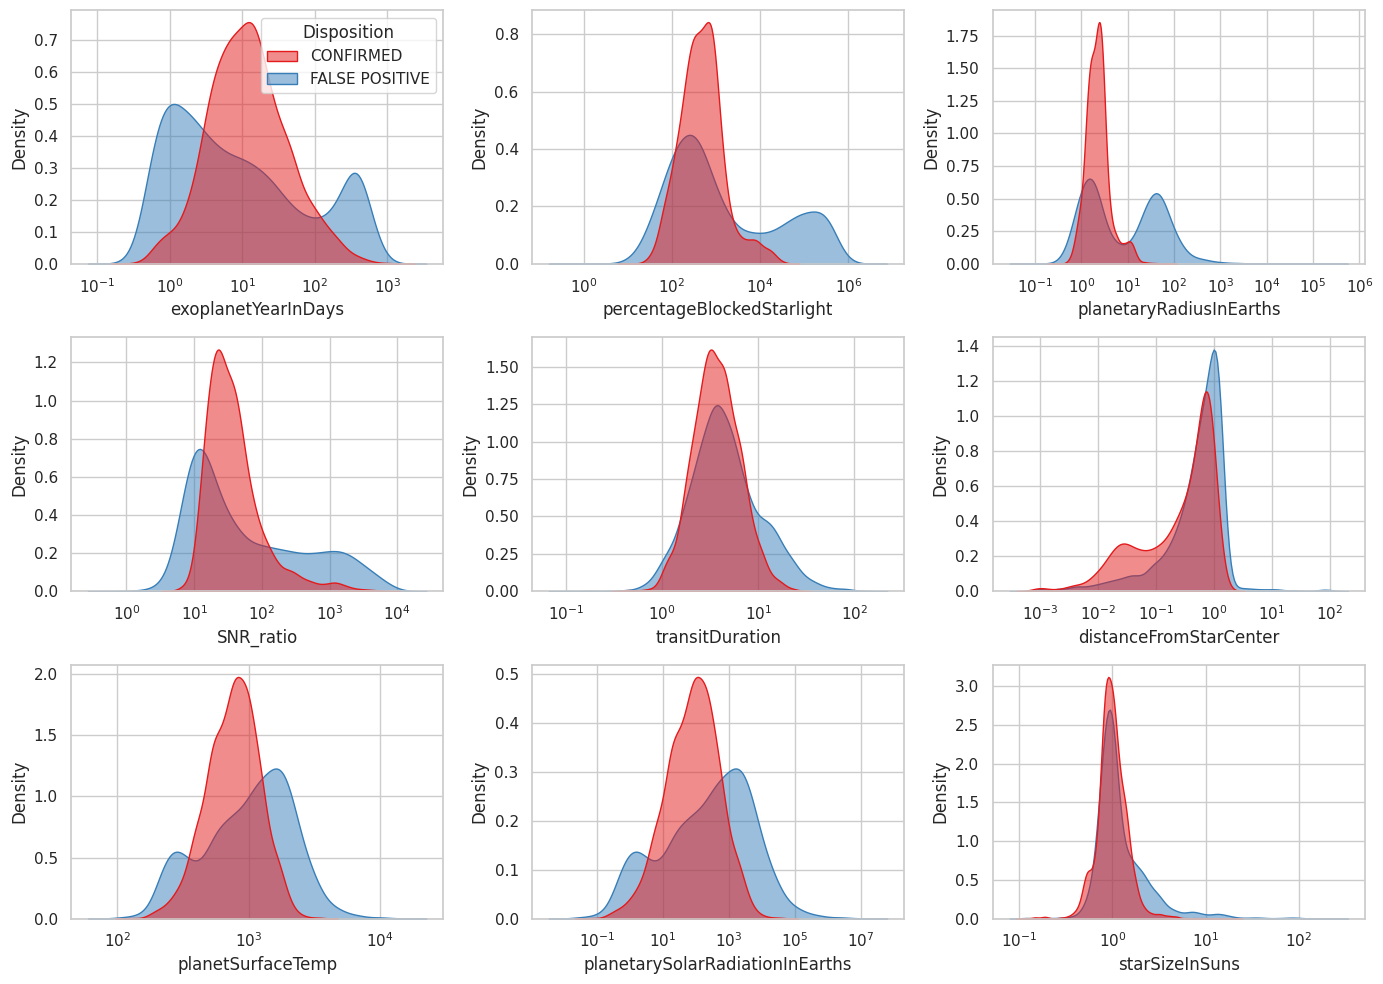

In [ ]:
# features to plot with KDEs
features = ['exoplanetYearInDays', 'percentageBlockedStarlight',
            'planetaryRadiusInEarths', 'SNR_ratio',
            'transitDuration', 'distanceFromStarCenter',
            'planetSurfaceTemp', 'planetarySolarRadiationInEarths',
            'starSizeInSuns']

# KDE Plots
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
keep_legend = False
for i, col in tuple(enumerate(features)):
    if i == 0:
      keep_legend = True # keeps legend only for first figure so we dont repeat it in all figures
    else:
      keep_legend = False
    # filtering for positive values to avoid log10(0) errors
    data_to_plot = df_cleaned[df_cleaned[col] > 0]
    sns.kdeplot(data=data_to_plot, x=col, hue='Disposition',
                log_scale=True, fill=True, ax=axes[i], common_norm=False, alpha=0.5, palette='Set1', legend=keep_legend) # common_norm = False makes area under each curve independently 1 rather than area under both curves sum to 1

plt.tight_layout()
plt.savefig('kde_plots_relevant.png')

The KDE plots reveal distinct differences in the feature distributions of confirmed exoplanets versus false positive signals. For example for planetary radius (planetaryRadiusInEarths) and transit depth (percentageBlockedStarlight), the confirmed class has a localized (low deviation), distribution centered at lower physical values, consistent with the expected dimensions of planetary bodies. In contrast, the false positive class has a broader, often multimodal distribution with density in the extreme upper ranges. This suggests that while confirmed planets are constrained by physical plausibility, false positives, often caused by eclipsing binaries or other physical phenomena such as gas formations, frequently exceed these limits.

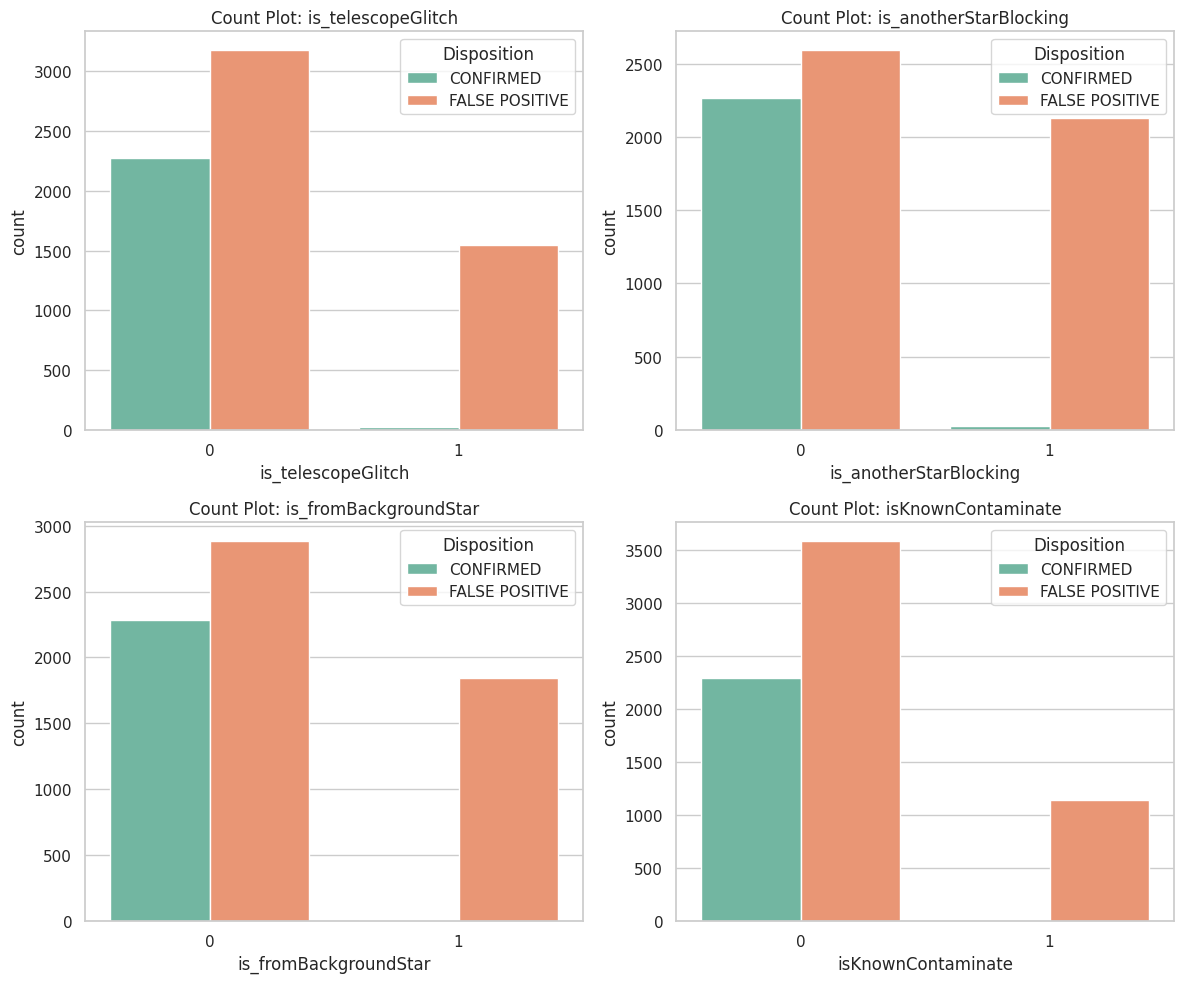

In [ ]:
# now we visualize the categorical features (the flags)
flag_features = [
    'is_telescopeGlitch',
    'is_anotherStarBlocking',
    'is_fromBackgroundStar',
    'isKnownContaminate',
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, feature in tuple(enumerate(flag_features)):

      sns.countplot(data=df_cleaned, x=feature, hue='Disposition', ax=axes[i], palette='Set2')
      axes[i].set_title(f'Count Plot: {feature}')


plt.tight_layout()
plt.savefig('flag_features_distribution.png')


relevant for scaling:
For the binary flags (is_telescopeGlitch, is_anotherStarBlocking, is_fromBackgroundStar, isKnownContaminate), the relationship is exceptionally clear:

"0" (False): Contains all the Confirmed exoplanets, mixed with some remaining False Positives that slipped past this specific check.

"1" (True): Almost exclusively contains False Positives. If a flag is triggered, the model can safely assume it is not a planet. is_anotherStarBlocking is the most frequently triggered flag.

This is data leakage, because these flags were created after analysis by NASA, and does not represent raw data. So we must remove them.

Keeping the flags causes data leakage. We want to predict based on physical and scientific measurements

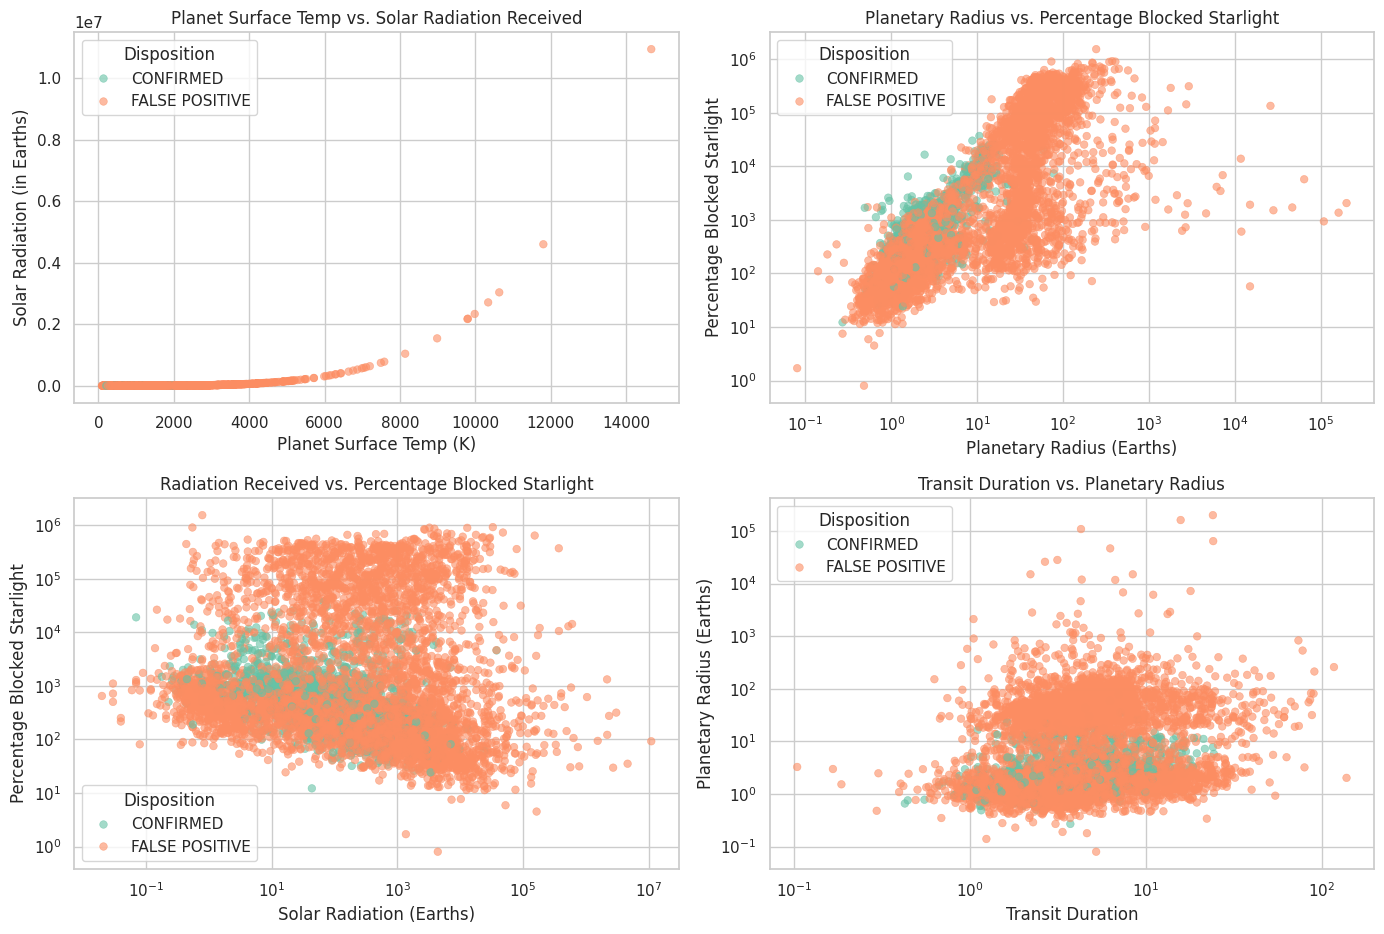

In [ ]:
sns.set_theme(style="whitegrid", palette="Set2")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 4 scatter plots: 2 with strong correlations between the features, 2 with weak.

# strong scatter plot 1: planet surface temperature vs solar radiation
# the stefan-boltzmann law describes the physical relationship between them, so there is curve
sns.scatterplot(data=df_cleaned, x='planetSurfaceTemp', y='planetarySolarRadiationInEarths', hue='Disposition',
                alpha=0.6, ax=axes[0], palette='Set2', s=30, edgecolor=None)

axes[0].set_title("Planet Surface Temp vs. Solar Radiation Received")
axes[0].set_xlabel("Planet Surface Temp (K)")
axes[0].set_ylabel("Solar Radiation (in Earths)")

# strong scatter plot 2: planetary radius vs % blocked starlight
sns.scatterplot(data=df_cleaned, x='planetaryRadiusInEarths', y='percentageBlockedStarlight', hue='Disposition',
                alpha=0.6, ax=axes[1], palette='Set2', s=30, edgecolor=None)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title("Planetary Radius vs. Percentage Blocked Starlight")
axes[1].set_xlabel("Planetary Radius (Earths)")
axes[1].set_ylabel("Percentage Blocked Starlight")

# weak scatter 1: radiation vs transit depth
sns.scatterplot(data=df_cleaned, x='planetarySolarRadiationInEarths', y='percentageBlockedStarlight', hue='Disposition',
                alpha=0.6, ax=axes[2], palette='Set2', s=30, edgecolor=None)
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].set_title("Radiation Received vs. Percentage Blocked Starlight")
axes[2].set_xlabel("Solar Radiation (Earths)")
axes[2].set_ylabel("Percentage Blocked Starlight")

# weak 2: transit duration vs planetary radius
sns.scatterplot(data=df_cleaned, x='transitDuration', y='planetaryRadiusInEarths', hue='Disposition',
                alpha=0.6, ax=axes[3], palette='Set2', s=30, edgecolor=None)
axes[3].set_xscale('log')
axes[3].set_yscale('log')
axes[3].set_title('Transit Duration vs. Planetary Radius')
axes[3].set_xlabel("Transit Duration")
axes[3].set_ylabel("Planetary Radius (Earths)")

plt.tight_layout(rect=[0, 0.05, 1, 1]) # adjust layout
plt.savefig('scatter_plots_mixed_correlations.png')

# Labeling & Scaling

In [ ]:
df_cleaned.head(15)

,Disposition,is_telescopeGlitch,is_anotherStarBlocking,is_fromBackgroundStar,isKnownContaminate,exoplanetYearInDays,astronomicalTimeWhenDetected,distanceFromStarCenter,transitDuration,percentageBlockedStarlight,planetaryRadiusInEarths,planetSurfaceTemp,planetarySolarRadiationInEarths,SNR_ratio,starSurfaceTemp,starSurfaceGravity,starSizeInSuns,longitudeStarInSky,latitudeStarInSky,starBrightnessFromKepler
0,CONFIRMED,0,0,0,0,9.488036,170.538750,0.146,2.95750,615.8,2.26,793.0,93.59,35.8,5455.0,4.467,0.927,291.93423,48.141651,15.347
1,CONFIRMED,0,0,0,0,54.418383,162.513840,0.586,4.50700,874.8,2.83,443.0,9.11,25.8,5455.0,4.467,0.927,291.93423,48.141651,15.347
2,FALSE POSITIVE,0,1,0,0,19.899140,175.850252,0.969,1.78220,10829.0,14.60,638.0,39.30,76.3,5853.0,4.544,0.868,297.00482,48.134129,15.436
3,FALSE POSITIVE,0,1,0,0,1.736952,170.307565,1.276,2.40641,8079.2,33.46,1395.0,891.96,505.6,5805.0,4.564,0.791,285.53461,48.285210,15.597
4,CONFIRMED,0,0,0,0,2.525592,171.595550,0.701,1.65450,603.3,2.75,1406.0,926.16,40.9,6031.0,4.438,1.046,288.75488,48.226200,15.509
5,CONFIRMED,0,0,0,0,11.094321,171.201160,0.538,4.59450,1517.5,3.90,835.0,114.81,66.5,6046.0,4.486,0.972,296.28613,48.224670,15.714
6,CONFIRMED,0,0,0,0,4.134435,172.979370,0.762,3.14020,686.0,2.77,1160.0,427.65,40.2,6046.0,4.486,0.972,296.28613,48.224670,15.714
7,CONFIRMED,0,0,0,0,2.566589,179.554370,0.755,2.42900,226.5,1.59,1360.0,807.74,15.0,6046.0,4.486,0.972,296.28613,48.224670,15.714
8,FALSE POSITIVE,0,1,1,0,7.361790,132.250530,1.169,5.02200,233.7,39.21,1342.0,767.22,47.7,6227.0,3.986,1.958,298.86435,42.151569,12.660
9,CONFIRMED,0,0,0,0,16.068647,173.621937,0.052,3.53470,4914.3,5.76,600.0,30.75,161.9,5031.0,4.485,0.848,286.99948,48.375790,15.841


In [ ]:
# now we label again
df_cleaned['Disposition'] = df_cleaned['Disposition'].replace(
    {'CONFIRMED': 1,
     'FALSE POSITIVE': 0}
    )

/tmp/ipykernel_827/2546270815.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cleaned['Disposition'] = df_cleaned['Disposition'].replace(


In [ ]:
df_cleaned.head(15)

,Disposition,is_telescopeGlitch,is_anotherStarBlocking,is_fromBackgroundStar,isKnownContaminate,exoplanetYearInDays,astronomicalTimeWhenDetected,distanceFromStarCenter,transitDuration,percentageBlockedStarlight,planetaryRadiusInEarths,planetSurfaceTemp,planetarySolarRadiationInEarths,SNR_ratio,starSurfaceTemp,starSurfaceGravity,starSizeInSuns,longitudeStarInSky,latitudeStarInSky,starBrightnessFromKepler
0,1,0,0,0,0,9.488036,170.538750,0.146,2.95750,615.8,2.26,793.0,93.59,35.8,5455.0,4.467,0.927,291.93423,48.141651,15.347
1,1,0,0,0,0,54.418383,162.513840,0.586,4.50700,874.8,2.83,443.0,9.11,25.8,5455.0,4.467,0.927,291.93423,48.141651,15.347
2,0,0,1,0,0,19.899140,175.850252,0.969,1.78220,10829.0,14.60,638.0,39.30,76.3,5853.0,4.544,0.868,297.00482,48.134129,15.436
3,0,0,1,0,0,1.736952,170.307565,1.276,2.40641,8079.2,33.46,1395.0,891.96,505.6,5805.0,4.564,0.791,285.53461,48.285210,15.597
4,1,0,0,0,0,2.525592,171.595550,0.701,1.65450,603.3,2.75,1406.0,926.16,40.9,6031.0,4.438,1.046,288.75488,48.226200,15.509
5,1,0,0,0,0,11.094321,171.201160,0.538,4.59450,1517.5,3.90,835.0,114.81,66.5,6046.0,4.486,0.972,296.28613,48.224670,15.714
6,1,0,0,0,0,4.134435,172.979370,0.762,3.14020,686.0,2.77,1160.0,427.65,40.2,6046.0,4.486,0.972,296.28613,48.224670,15.714
7,1,0,0,0,0,2.566589,179.554370,0.755,2.42900,226.5,1.59,1360.0,807.74,15.0,6046.0,4.486,0.972,296.28613,48.224670,15.714
8,0,0,1,1,0,7.361790,132.250530,1.169,5.02200,233.7,39.21,1342.0,767.22,47.7,6227.0,3.986,1.958,298.86435,42.151569,12.660
9,1,0,0,0,0,16.068647,173.621937,0.052,3.53470,4914.3,5.76,600.0,30.75,161.9,5031.0,4.485,0.848,286.99948,48.375790,15.841


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # we saw earlier with KDEs that our data is normally distributed; logistic regression assumes so anyway

X = df_cleaned.drop(columns=['Disposition'])
y = df_cleaned['Disposition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
# stratified sampling since our data is imbalanced

# making columns for scaling; flag features will not be scaled
binary_cols = ['is_telescopeGlitch', 'is_anotherStarBlocking', 'is_fromBackgroundStar', 'isKnownContaminate']
continuous_cols = [col for col in X.columns if col not in binary_cols]

scaler = StandardScaler()

# scale the training data
# we fit only on training data to prevent data leakage from test set
X_train_cont_scaled = scaler.fit_transform(X_train[continuous_cols])
              #only cont. cols, not flags because we dont want to transform they are binary
X_train_cont_scaled_df = pd.DataFrame(X_train_cont_scaled, columns=continuous_cols, index=X_train.index)

#scale testing data using scaler that learned from training data
X_test_cont_scaled = scaler.transform(X_test[continuous_cols])
X_test_cont_scaled_df = pd.DataFrame(X_test_cont_scaled, columns=continuous_cols, index=X_test.index)

#recombine between scaled and unscaled
X_train_scaled = pd.concat([X_train_cont_scaled_df, X_train[binary_cols]], axis=1)
X_test_scaled = pd.concat([X_test_cont_scaled_df, X_test[binary_cols]], axis=1)



# Using Decision Tree to extract most important features

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_baseline = DecisionTreeClassifier(random_state=42)
tree_baseline.fit(X_train_scaled, y_train)

importances = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': tree_baseline.feature_importances_
}).sort_values(by='Importance', ascending=False)
#extracting feature importances as a dataframe
importances

,Feature,Importance
15,is_telescopeGlitch,0.332024
17,is_fromBackgroundStar,0.248030
5,planetaryRadiusInEarths,0.212942
18,isKnownContaminate,0.082251
16,is_anotherStarBlocking,0.063966
8,SNR_ratio,0.019117
1,astronomicalTimeWhenDetected,0.006624
9,starSurfaceTemp,0.006445
2,distanceFromStarCenter,0.006086
0,exoplanetYearInDays,0.006041


/tmp/ipykernel_827/149036257.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')


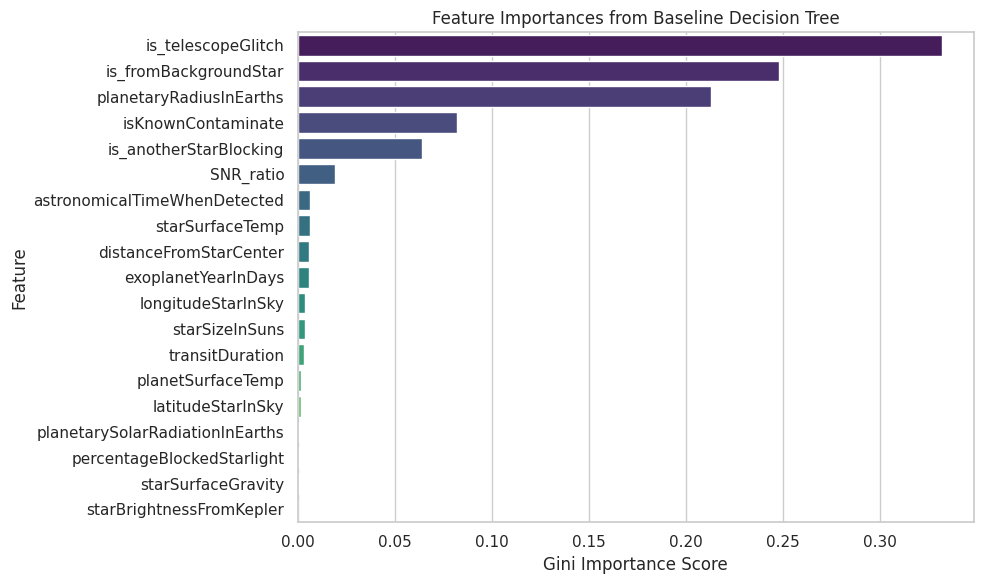

In [ ]:
# visualize importances dataframe
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')
plt.title('Feature Importances from Baseline Decision Tree')
plt.xlabel('Gini Importance Score')
plt.tight_layout()
plt.savefig('feature_importances.png')
plt.show()

The flags dominate. This shows the consequences of the data leakage from the flags. Thus, we will remake the model removing the flags from the data.

In [ ]:
flags_to_drop = ['is_telescopeGlitch', 'is_anotherStarBlocking', 'is_fromBackgroundStar', 'isKnownContaminate']

X_train_physics = X_train_scaled.drop(columns=flags_to_drop) #as in, only physics-related features (no flags)
X_test_physics = X_test_scaled.drop(columns=flags_to_drop)

tree_physics = DecisionTreeClassifier(random_state=42) #retraining on only real, physics features
tree_physics.fit(X_train_physics, y_train)

importances_physics = pd.DataFrame({
    'Feature': X_train_physics.columns,
    'Importance': tree_physics.feature_importances_
}).sort_values(by='Importance', ascending=False)

importances_physics.reset_index().drop('index', axis=1)

,Feature,Importance
0,SNR_ratio,0.241897
1,planetaryRadiusInEarths,0.238924
2,exoplanetYearInDays,0.159945
3,transitDuration,0.090323
4,distanceFromStarCenter,0.051083
5,longitudeStarInSky,0.039812
6,starSurfaceGravity,0.026041
7,latitudeStarInSky,0.024378
8,planetarySolarRadiationInEarths,0.021870
9,planetSurfaceTemp,0.021268


/tmp/ipykernel_827/3459705752.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y="Feature", data=importances_physics, palette='viridis')


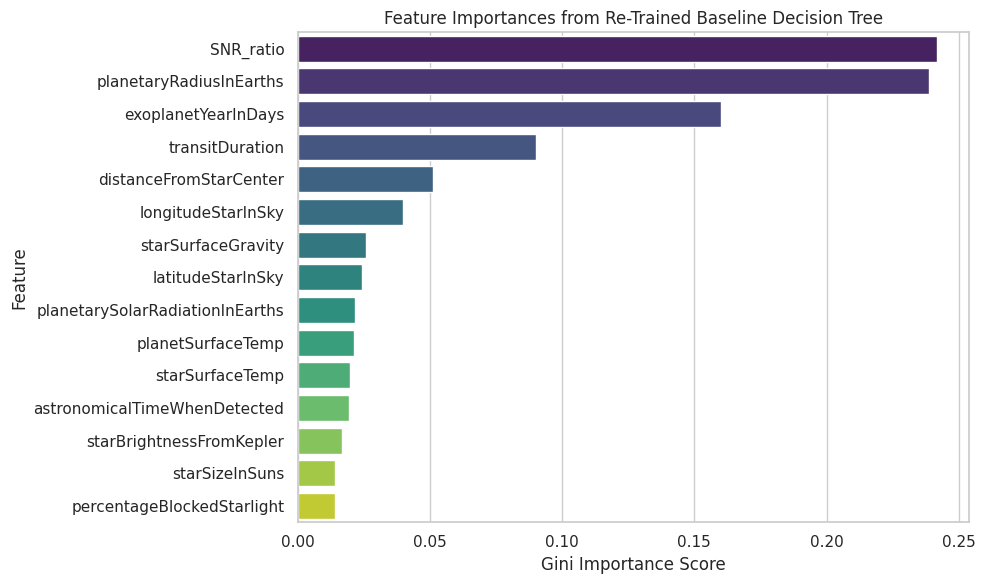

In [ ]:
#importances from only physics based features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y="Feature", data=importances_physics, palette='viridis')
plt.title('Feature Importances from Re-Trained Baseline Decision Tree')
plt.xlabel('Gini Importance Score')
plt.tight_layout()
plt.savefig('physics_feature_importances.png')
plt.show()

This is much more even and useful

Now we have the most important features. We will now remove all features that contribute to less than 0.1 % of the model.

In [ ]:
# filtering out irrelevant columns (more Dimensionality Reduction after previous sections)

# keeping only features that contribute at least 0.1% to the model, because the flags dominate
threshold = 0.01
top_features_physics = importances_physics[importances_physics['Importance'] >= threshold]['Feature'].tolist()

# apply dim. reduction to both training and testing
X_train_final = X_train_physics[top_features_physics]
X_test_final = X_test_physics[top_features_physics]
top_features_physics


['SNR_ratio',
 'planetaryRadiusInEarths',
 'exoplanetYearInDays',
 'transitDuration',
 'distanceFromStarCenter',
 'longitudeStarInSky',
 'starSurfaceGravity',
 'latitudeStarInSky',
 'planetarySolarRadiationInEarths',
 'planetSurfaceTemp',
 'starSurfaceTemp',
 'astronomicalTimeWhenDetected',
 'starBrightnessFromKepler',
 'starSizeInSuns',
 'percentageBlockedStarlight']

In [ ]:
list(importances_physics['Feature']) == top_features_physics

True

No features have been dropped. After flags were removed all this data is relevant to the model

# Building, Applying and Testing Models

Now we use decision tree algorithm for the model. first we use grid search and cross validation to optimize.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, classification_report

params_grid = {
    'max_depth': [None, 3, 5, 10, 15],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion': ['gini', 'entropy']
}

base_tree = DecisionTreeClassifier(random_state=42)

grid_search_tree = GridSearchCV(estimator=base_tree,
                                param_grid=params_grid,
                                cv=5,                   # 5 fold cross validation
                                scoring='f1',
                                n_jobs=-1)              # n_jobs=-1 uses all CPU cores to run faster

# running search, 120 from params_grid x 5 folds = will train 600 combinations
grid_search_tree.fit(X_train_final, y_train)

best_tree = grid_search_tree.best_estimator_ #best from grid search

best_tree

DecisionTreeClassifier(min_samples_leaf=20, random_state=42)

In [ ]:
print(f"Best Hyperparameters Found: {grid_search_tree.best_params_}")
print(f"Best Cross-Validation F1: {grid_search_tree.best_score_:.4f}")

#final evaluation based on unseen set
y_pred_tree = best_tree.predict(X_test_final)
test_f1 = f1_score(y_test, y_pred_tree)

print(f"Final Test F1 (Unseen Data): {test_f1:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_tree))

Best Hyperparameters Found: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 20, 'min_samples_split': 2}
Best Cross-Validation F1: 0.8478
Final Test F1 (Unseen Data): 0.8408
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.93       945
           1       0.86      0.82      0.84       458

    accuracy                           0.90      1403
   macro avg       0.89      0.88      0.88      1403
weighted avg       0.90      0.90      0.90      1403



Now we do the same for logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression

# C controls regularization (smaller C -> stronger penalty +simpler model)
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'solver': ['lbfgs'], # standard solver for logistic regression
    'max_iter': [2000]   # to allow gradient descent to converge (more iters -> greater chance of convergence)
}

base_logreg = LogisticRegression(random_state=42)

grid_search_lr = GridSearchCV(estimator=base_logreg,
                              param_grid=param_grid_lr,
                              cv=5,
                              scoring='f1',
                              n_jobs=-1)

grid_search_lr.fit(X_train_final, y_train)

best_logreg = grid_search_lr.best_estimator_
best_logreg

LogisticRegression(C=1000, max_iter=2000, random_state=42)

In [ ]:
print(f"Best Hyperparameters Found: {grid_search_lr.best_params_}")
print(f"Best Cross-Validation F1: {grid_search_lr.best_score_:.4f}")

y_pred_lr = best_logreg.predict(X_test_final)
test_f1_lr = f1_score(y_test, y_pred_lr)

print(f"Final Test F1 (Unseen Data): {test_f1_lr:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

Best Hyperparameters Found: {'C': 1000, 'max_iter': 2000, 'solver': 'lbfgs'}
Best Cross-Validation F1: 0.7692
Final Test F1 (Unseen Data): 0.7606
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88       945
           1       0.74      0.78      0.76       458

    accuracy                           0.84      1403
   macro avg       0.82      0.82      0.82      1403
weighted avg       0.84      0.84      0.84      1403



Now we test the same things but *with* data leakage (the flag features)

In [ ]:
X_train_scaled.columns
#X_train_scaled has the flags

Index(['exoplanetYearInDays', 'astronomicalTimeWhenDetected',
       'distanceFromStarCenter', 'transitDuration',
       'percentageBlockedStarlight', 'planetaryRadiusInEarths',
       'planetSurfaceTemp', 'planetarySolarRadiationInEarths', 'SNR_ratio',
       'starSurfaceTemp', 'starSurfaceGravity', 'starSizeInSuns',
       'longitudeStarInSky', 'latitudeStarInSky', 'starBrightnessFromKepler',
       'is_telescopeGlitch', 'is_anotherStarBlocking', 'is_fromBackgroundStar',
       'isKnownContaminate'],
      dtype='object')

In [ ]:
# 1) decision tree with leakage

#dt = decision tree, dl = data leakage
params_grid_dt_dl = {
    'max_depth': [None, 3, 5, 10, 15],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion': ['gini', 'entropy']
}

# using X_train_scaled, which has the four flags
grid_search_dt_flags = GridSearchCV(DecisionTreeClassifier(random_state=42),
                                    param_grid=params_grid_dt_dl,
                                    cv=5, n_jobs=-1)
grid_search_dt_flags.fit(X_train_scaled, y_train)

best_dt_flags = grid_search_dt_flags.best_estimator_
y_pred_dt_flags = best_dt_flags.predict(X_test_scaled)

best_dt_flags

DecisionTreeClassifier(min_samples_leaf=20, random_state=42)

In [ ]:
print(f"Best Hyperparameters: {grid_search_dt_flags.best_params_}")
print(f"Best CV F1: {grid_search_dt_flags.best_score_:.4f}")
print(f"Final Test F1 (With Flags): {f1_score(y_test, y_pred_dt_flags):.4f}\n")

print("--- Classification Report (Decision Tree w/ Flags) ---")
print(classification_report(y_test, y_pred_dt_flags))

Best Hyperparameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 20, 'min_samples_split': 2}
Best CV F1: 0.9861
Final Test F1 (With Flags): 0.9712

--- Classification Report (Decision Tree w/ Flags) ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       945
           1       0.99      0.96      0.97       458

    accuracy                           0.98      1403
   macro avg       0.98      0.97      0.98      1403
weighted avg       0.98      0.98      0.98      1403



In [ ]:
# 2) logistic Regression with leakage

param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'solver': ['lbfgs'],
    'max_iter': [2000]
}

grid_search_lr_flags = GridSearchCV(LogisticRegression(random_state=42),
                                    param_grid=param_grid_lr, cv=5, n_jobs=-1)
grid_search_lr_flags.fit(X_train_scaled, y_train)

best_lr_flags = grid_search_lr_flags.best_estimator_
y_pred_lr_flags = best_lr_flags.predict(X_test_scaled)
best_lr_flags

LogisticRegression(C=10, max_iter=2000, random_state=42)

In [ ]:
print(f"Best Hyperparameters: {grid_search_lr_flags.best_params_}")
print(f"Best CV F1: {grid_search_lr_flags.best_score_:.4f}")
print(f"Final Test F1 (With Flags): {f1_score(y_test, y_pred_lr_flags):.4f}\n")

print("--- Classification Report (Logistic Regression w/ Flags) ---")
print(classification_report(y_test, y_pred_lr_flags))

Best Hyperparameters: {'C': 10, 'max_iter': 2000, 'solver': 'lbfgs'}
Best CV F1: 0.9854
Final Test F1 (With Flags): 0.9748

--- Classification Report (Logistic Regression w/ Flags) ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       945
           1       0.98      0.97      0.97       458

    accuracy                           0.98      1403
   macro avg       0.98      0.98      0.98      1403
weighted avg       0.98      0.98      0.98      1403



It is natural that with data leakage the results will be better. However we cannot use data that comes with foreknowledge of the results; we must use only raw data.

# Results Visual Analysis

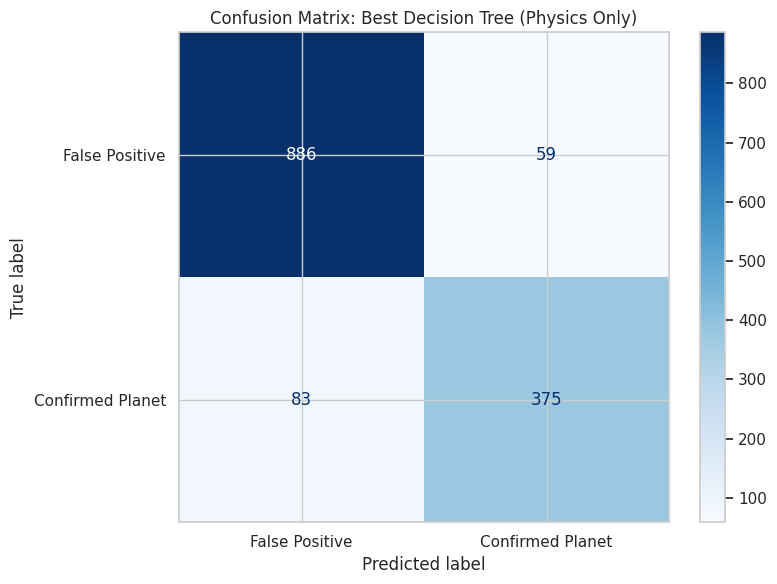

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

y_pred_winning = best_tree.predict(X_test_final)
cm = confusion_matrix(y_test, y_pred_winning)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['False Positive', 'Confirmed Planet'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix: Best Decision Tree (Physics Only)')
plt.tight_layout()
plt.savefig('confusion_matrix_final.png')
plt.show()


In [ ]:

#probabilities of a planet existing
y_prob_winning = best_tree.predict_proba(X_test_final)[:, 1]

# Calculate False Positive Rate, True Positive Rate, and Area Under Curve (AUC)
fpr, tpr, thresholds = roc_curve(y_test, y_prob_winning)
roc_auc = auc(fpr, tpr)

res = {"y_prob_winning": y_prob_winning, 'fpr': fpr, "tpr": tpr, "thresholds": thresholds}
res

{'y_prob_winning': array([0.  , 1.  , 0.85, ..., 0.  , 0.  , 1.  ]),
 'fpr': array([0.        , 0.02116402, 0.02116402, 0.02116402, 0.02433862,
        0.02433862, 0.02433862, 0.02751323, 0.02857143, 0.02857143,
        0.02962963, 0.02962963, 0.03280423, 0.03386243, 0.03703704,
        0.04021164, 0.04126984, 0.04232804, 0.04444444, 0.04444444,
        0.04867725, 0.04973545, 0.05079365, 0.05079365, 0.05079365,
        0.05396825, 0.05396825, 0.05396825, 0.05820106, 0.06243386,
        0.07089947, 0.07830688, 0.08783069, 0.0952381 , 0.1047619 ,
        0.11005291, 0.11111111, 0.11851852, 0.14074074, 0.14497354,
        0.15026455, 0.15978836, 0.17037037, 0.17142857, 0.17671958,
        0.18412698, 0.1968254 , 0.2031746 , 0.21164021, 0.23597884,
        0.24021164, 0.25925926, 0.26137566, 0.26878307, 0.27724868,
        1.        ]),
 'tpr': array([0.        , 0.4650655 , 0.47598253, 0.49126638, 0.51091703,
        0.53056769, 0.54585153, 0.55676856, 0.56113537, 0.57860262,
        0.5

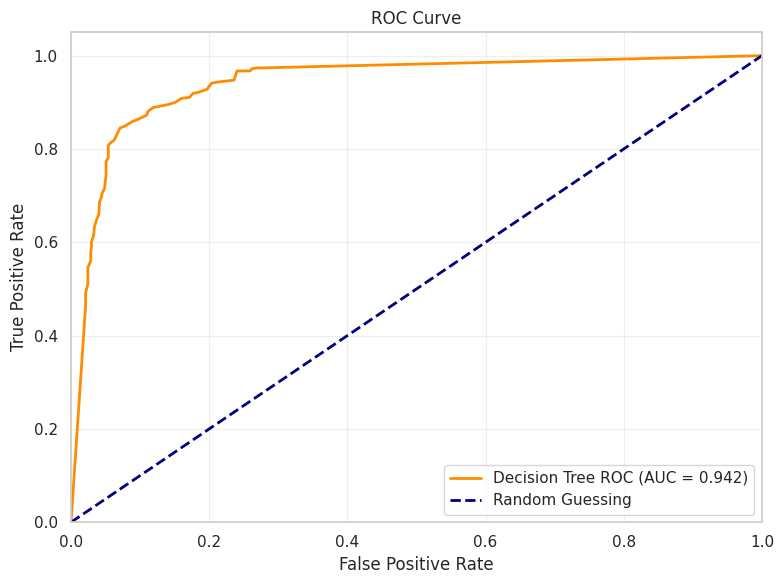


Final AUC Score: 0.942


In [ ]:

#plot roc curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f'Decision Tree ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_final.png')
plt.show()

print(f"\nFinal AUC Score: {roc_auc:.3f}")

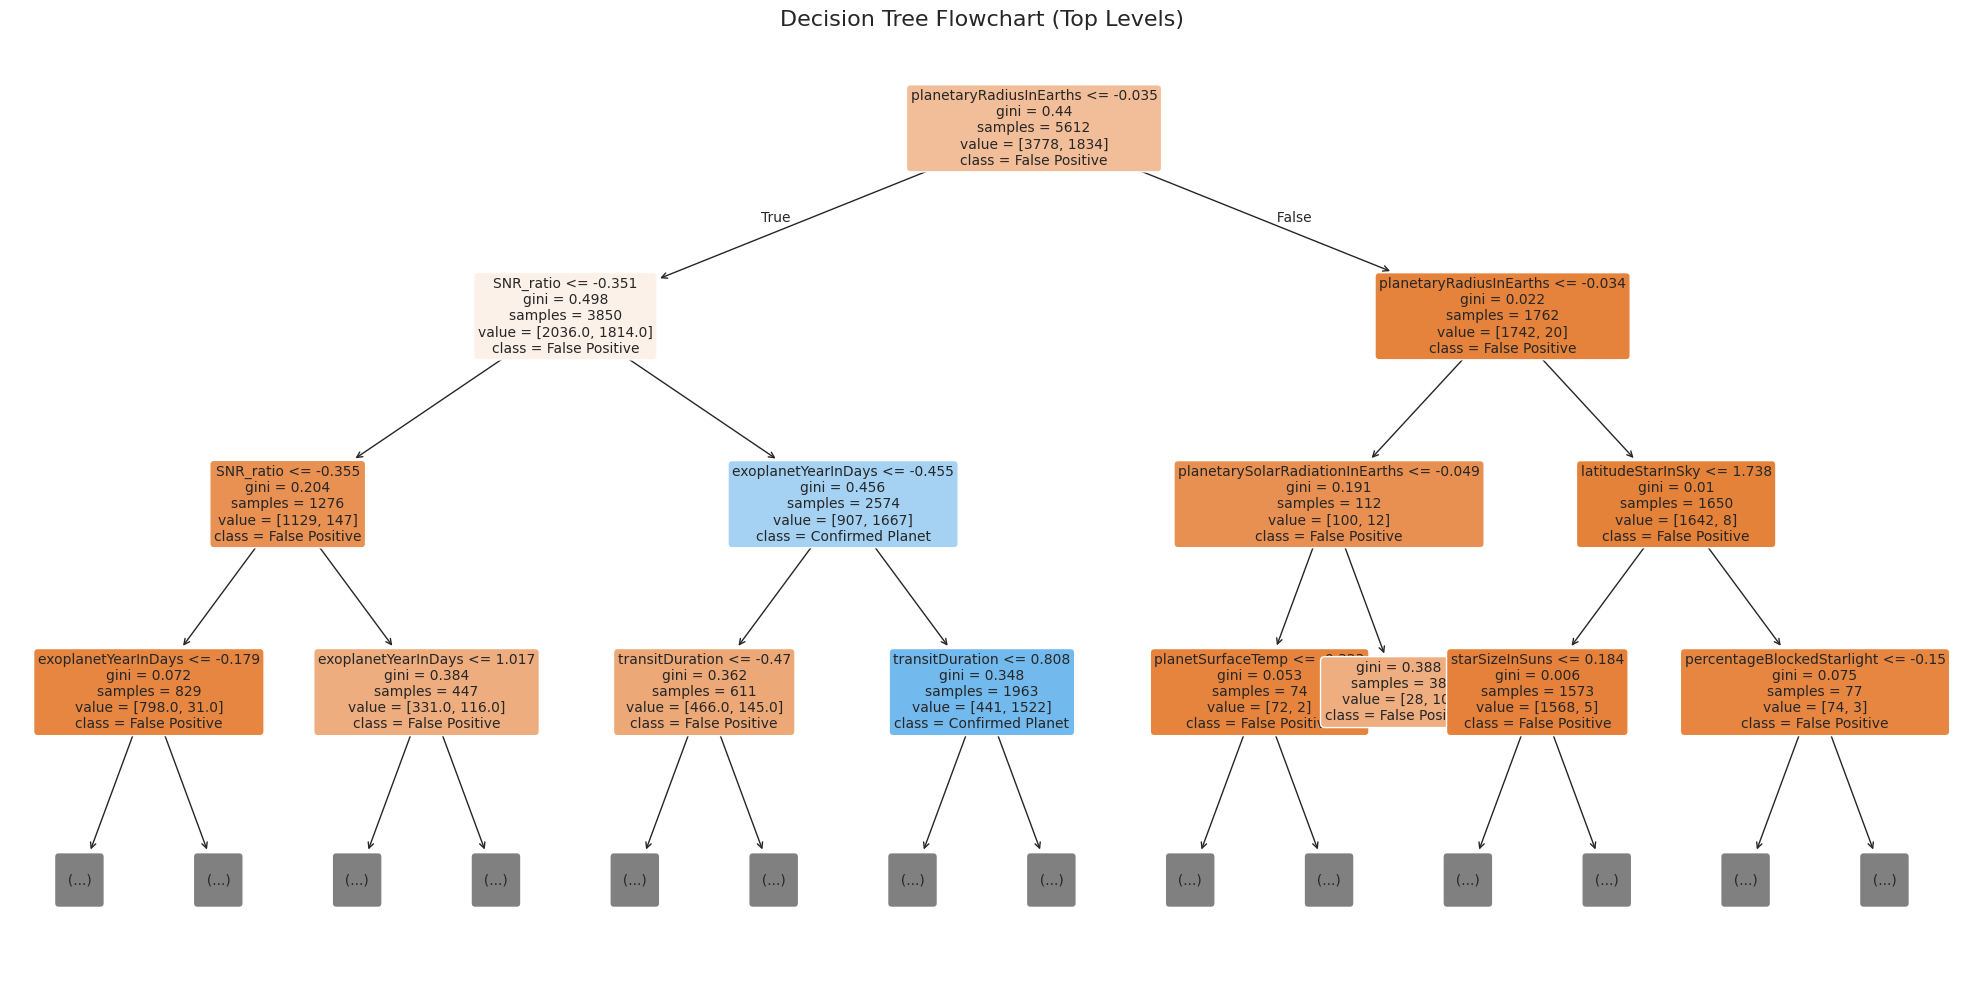

In [ ]:
from sklearn.tree import plot_tree

#visualizing the tree
plt.figure(figsize=(20, 10))
# imperfectly draw the first few layers of best_tree
plot_tree(best_tree,
          max_depth=3,
          feature_names=X_train_final.columns,
          class_names=['False Positive', 'Confirmed Planet'],
          filled=True,
          rounded=True,
          fontsize=10)

plt.title('Decision Tree Flowchart (Top Levels)', fontsize=16)
plt.tight_layout()
plt.savefig('decision_tree_flowchart.png')
plt.show()

In [ ]:
print(f"The depth of the optimized decision tree is: {best_tree.get_depth()}")

The depth of the optimized decision tree is: 18


Showing the parameters and hyperparameters of our 4 models (Decision Tree with flags, Decision Tree without Flags, Logistic Regression with Flags, Logistic Regression without Flags)

In [ ]:
# 1. Parameters for Decision Tree (Physics Only)
print("Tuned Hyperparameters (from Grid Search):")
for param, value in grid_search_tree.best_params_.items():
    print(f" - {param}: {value}")

print("All Model Parameters:")
for param, value in best_tree.get_params().items():
    print(f" - {param}: {value}")

Tuned Hyperparameters (from Grid Search):
 - criterion: gini
 - max_depth: None
 - min_samples_leaf: 20
 - min_samples_split: 2
All Model Parameters:
 - ccp_alpha: 0.0
 - class_weight: None
 - criterion: gini
 - max_depth: None
 - max_features: None
 - max_leaf_nodes: None
 - min_impurity_decrease: 0.0
 - min_samples_leaf: 20
 - min_samples_split: 2
 - min_weight_fraction_leaf: 0.0
 - monotonic_cst: None
 - random_state: 42
 - splitter: best


In [ ]:
# 2. Parameters for Logistic Regression (Physics Only)
print("Tuned Hyperparameters (from Grid Search):")
for param, value in grid_search_lr.best_params_.items():
    print(f" - {param}: {value}")

print("All Model Parameters:")
for param, value in best_logreg.get_params().items():
    print(f" - {param}: {value}")


Tuned Hyperparameters (from Grid Search):
 - C: 1000
 - max_iter: 2000
 - solver: lbfgs
All Model Parameters:
 - C: 1000
 - class_weight: None
 - dual: False
 - fit_intercept: True
 - intercept_scaling: 1
 - l1_ratio: None
 - max_iter: 2000
 - multi_class: deprecated
 - n_jobs: None
 - penalty: l2
 - random_state: 42
 - solver: lbfgs
 - tol: 0.0001
 - verbose: 0
 - warm_start: False


In [ ]:
# 3. Parameters for Decision Tree (With Flags)
print("Tuned Hyperparameters (from Grid Search):")
for param, value in grid_search_dt_flags.best_params_.items():
    print(f" - {param}: {value}")

print("All Model Parameters:")
for param, value in best_dt_flags.get_params().items():
    print(f" - {param}: {value}")


Tuned Hyperparameters (from Grid Search):
 - criterion: gini
 - max_depth: None
 - min_samples_leaf: 20
 - min_samples_split: 2
All Model Parameters:
 - ccp_alpha: 0.0
 - class_weight: None
 - criterion: gini
 - max_depth: None
 - max_features: None
 - max_leaf_nodes: None
 - min_impurity_decrease: 0.0
 - min_samples_leaf: 20
 - min_samples_split: 2
 - min_weight_fraction_leaf: 0.0
 - monotonic_cst: None
 - random_state: 42
 - splitter: best


In [ ]:
# 4. Parameters for Logistic Regression (With Flags)
print("Tuned Hyperparameters (from Grid Search):")
for param, value in grid_search_lr_flags.best_params_.items():
    print(f" - {param}: {value}")

print("All Model Parameters:")
for param, value in best_lr_flags.get_params().items():
    print(f" - {param}: {value}")


Tuned Hyperparameters (from Grid Search):
 - C: 10
 - max_iter: 2000
 - solver: lbfgs
All Model Parameters:
 - C: 10
 - class_weight: None
 - dual: False
 - fit_intercept: True
 - intercept_scaling: 1
 - l1_ratio: None
 - max_iter: 2000
 - multi_class: deprecated
 - n_jobs: None
 - penalty: l2
 - random_state: 42
 - solver: lbfgs
 - tol: 0.0001
 - verbose: 0
 - warm_start: False
